In [5]:
# loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as  sns

In [6]:
#laod the data
import glob
def load_data(folder_path):
    """Load the dataset from .pkl files in the specified folder."""
    try:
        # Load all .pkl files in the folder
        all_files = glob.glob(folder_path + "./*.pkl")
        data_list = [pd.read_pickle(file) for file in all_files]
        
        # Combine all data into a single DataFrame
        data = pd.concat(data_list, ignore_index=True)
        print("Datasets loaded and combined successfully.")
        return data
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None


In [7]:
def perform_eda(data):
    """Perform basic exploratory data analysis on the dataset."""
    print("\nBasic Information about the dataset:")
    print(data.info())
    
    print("\nSummary Statistics:")
    print(data.describe())

    print("\nChecking for Missing Values:")
    print(data.isnull().sum())

    print("\nClass Distribution:")
    print(data['TX_FRAUD'].value_counts())
    
    sns.countplot(x='TX_FRAUD', data=data)
    plt.title("Class Distribution (Fraud vs Legitimate)")
    plt.show()

    # Visualizing Transaction Amount Distribution
    sns.boxplot(x='TX_FRAUD', y='TX_AMOUNT', data=data)
    plt.title("Transaction Amount Distribution by Class")
    plt.show()


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preprocess_data(data):
    """Preprocess the dataset for model training."""
    # Drop duplicates, if any
    data = data.drop_duplicates()

    # Handle missing values (if any exist)
    data = data.fillna(method='ffill').fillna(method='bfill')

    # Feature Engineering: Convert TX_DATETIME to datetime and extract useful features
    data['TX_DATETIME'] = pd.to_datetime(data['TX_DATETIME'])
    data['TX_HOUR'] = data['TX_DATETIME'].dt.hour
    data['TX_DAY'] = data['TX_DATETIME'].dt.day
    data['TX_MONTH'] = data['TX_DATETIME'].dt.month

    # Scenario-based Feature Engineering
    # Adding a flag for transactions above 220 (obvious fraud pattern)
    data['FLAG_AMOUNT_ABOVE_220'] = (data['TX_AMOUNT'] > 220).astype(int)

    # Adding rolling features for terminal-based fraud
    data['TERMINAL_FRAUD_COUNT'] = data.groupby('TERMINAL_ID')['TX_FRAUD'].rolling(window=28, min_periods=1).sum().reset_index(0, drop=True)

    # Adding rolling features for customer-based fraud
    data['CUSTOMER_SPENDING_14D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling(window=14, min_periods=1).mean().reset_index(0, drop=True)
    data['CUSTOMER_FRAUD_COUNT'] = data.groupby('CUSTOMER_ID')['TX_FRAUD'].rolling(window=14, min_periods=1).sum().reset_index(0, drop=True)

    # Drop unnecessary columns
    data = data.drop(columns=['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID'])

    # Separating features and target variable
    X = data.drop(columns=['TX_FRAUD'])
    y = data['TX_FRAUD']

    # Splitting the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Scaling the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test



In [11]:
from sklearn.ensemble import RandomForestClassifier

 #Model Training
def train_model(X_train, y_train):
    """Train a Random Forest Classifier on the dataset."""
    model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, class_weight="balanced")
    model.fit(X_train, y_train)
    print("Model training complete.")
    return model


In [12]:
 #Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_test, y_test):
    """Evaluate the trained model on the test dataset."""
    y_pred = model.predict(X_test)

    print("\nConfusion Matrix:")
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nAccuracy Score:")
    print(accuracy_score(y_test, y_pred))


Datasets loaded and combined successfully.

Basic Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB
None

Summary Statistics:
       TRANSACTION_ID                    TX_DATETIME     TX_AMOUNT  \
count    1.754155e+06                        1754155  1.754155e+06   
mean     8.770770e+05  2018-07-01 11:20:33.708572160  5.363230e+01   
min      0.000000e+00            2018-04-01 00:00:31  0.000

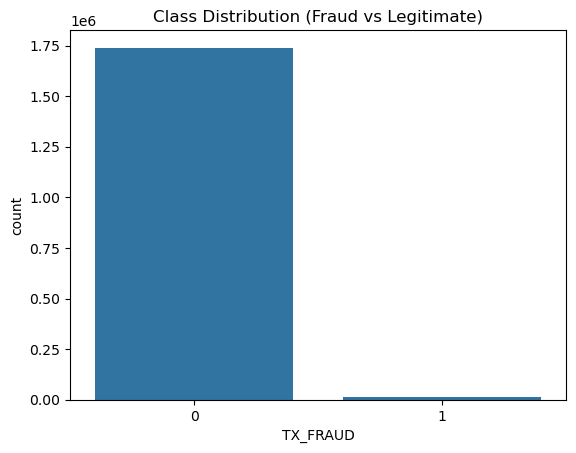

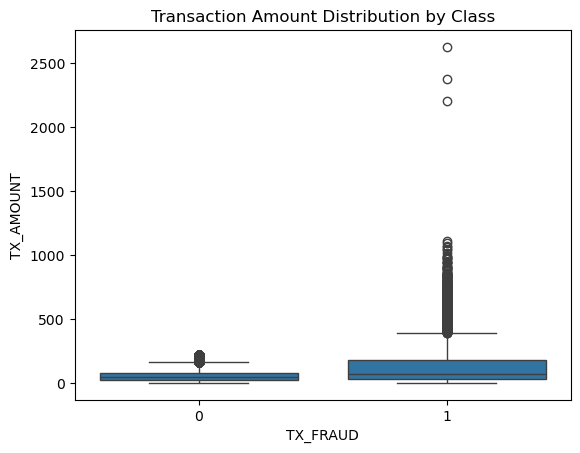

C:\Users\swanand\AppData\Local\Temp\ipykernel_13168\2908493645.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')
C:\Users\swanand\AppData\Local\Temp\ipykernel_13168\2908493645.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.fillna(method='ffill').fillna(method='bfill')


Model training complete.

Confusion Matrix:


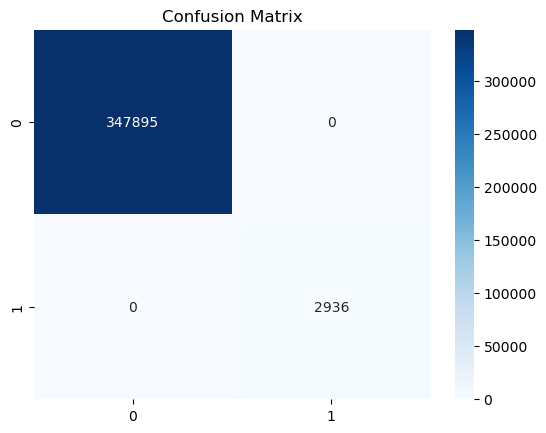


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    347895
           1       1.00      1.00      1.00      2936

    accuracy                           1.00    350831
   macro avg       1.00      1.00      1.00    350831
weighted avg       1.00      1.00      1.00    350831


Accuracy Score:
1.0


In [13]:
# Main function to execute all steps
def main():
    folder_path = './data'  # Update with the folder containing your .pkl files

    # Load the data
    data = load_data(folder_path)
    if data is None:
        return

    # Perform EDA
    perform_eda(data)

    # Preprocess the data
    X_train, X_test, y_train, y_test = preprocess_data(data)

    # Train the model
    model = train_model(X_train, y_train)

    # Evaluate the model
    evaluate_model(model, X_test, y_test)



if __name__ == "__main__":
    main()



In [2]:
from manim import *

class Presentation(Scene):
    def construct(self):
        title = Text("Fraud Detection Presentation")
        self.play(Write(title))
        self.wait(2)


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject